# 📊 ROC Curve in Machine Learning

## 📋 Overview
**ROC (Receiver Operating Characteristic) Curve** is a graphical plot that illustrates the diagnostic ability of a binary classifier system as its discrimination threshold is varied. It's one of the most important evaluation metrics for binary classification problems.

---

## 🎯 Core Concept

### Definition
The ROC curve plots **True Positive Rate (TPR)** against **False Positive Rate (FPR)** at various threshold settings.

$$\text{TPR} = \frac{\text{TP}}{\text{TP} + \text{FN}} = \frac{\text{TP}}{P}$$

$$\text{FPR} = \frac{\text{FP}}{\text{FP} + \text{TN}} = \frac{\text{FP}}{N}$$

where:
- $\text{TP}$ = True Positives
- $\text{FP}$ = False Positives  
- $\text{TN}$ = True Negatives
- $\text{FN}$ = False Negatives
- $P$ = Total actual positives
- $N$ = Total actual negatives

### Alternative Names
- **TPR** = Sensitivity = Recall = Hit Rate
- **FPR** = 1 - Specificity = Fall-out
- **TNR** = Specificity = 1 - FPR

---

## 📈 Confusion Matrix Foundation

### 2×2 Confusion Matrix
```
                    Predicted
                 Positive  Negative
Actual Positive    TP       FN
       Negative    FP       TN
```

### Key Metrics Derived
$$\text{Accuracy} = \frac{\text{TP} + \text{TN}}{\text{TP} + \text{TN} + \text{FP} + \text{FN}}$$

$$\text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}}$$

$$\text{Recall (TPR)} = \frac{\text{TP}}{\text{TP} + \text{FN}}$$

$$\text{Specificity (TNR)} = \frac{\text{TN}}{\text{TN} + \text{FP}}$$

$$\text{F1-Score} = 2 \cdot \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

---

## 🔍 ROC Curve Construction

### Step-by-Step Process
1. **Train classifier** that outputs probabilities $P(y=1|x)$
2. **Sort test samples** by predicted probability (descending)
3. **For each threshold** $t \in [0, 1]$:
   - Classify: $\hat{y} = \mathbb{I}[P(y=1|x) \geq t]$
   - Calculate TPR and FPR
   - Plot point (FPR, TPR)
4. **Connect points** to form ROC curve

### Mathematical Representation
For threshold $t$:
$$\text{TPR}(t) = P(\hat{P} \geq t | Y = 1)$$
$$\text{FPR}(t) = P(\hat{P} \geq t | Y = 0)$$

where $\hat{P}$ is the predicted probability and $Y$ is the true label.

---

## 📏 Area Under the Curve (AUC)

### Definition
$$\text{AUC} = \int_0^1 \text{TPR}(\text{FPR}^{-1}(x)) \, dx$$

### Probabilistic Interpretation
AUC represents the probability that a randomly chosen positive instance is ranked higher than a randomly chosen negative instance:

$$\text{AUC} = P(\text{score}(\text{positive}) > \text{score}(\text{negative}))$$

### Discrete Approximation
For $n$ thresholds:
$$\text{AUC} \approx \sum_{i=1}^{n-1} \frac{1}{2}(\text{TPR}_i + \text{TPR}_{i+1})(\text{FPR}_{i+1} - \text{FPR}_i)$$

### Wilcoxon-Mann-Whitney Statistic
$$\text{AUC} = \frac{1}{n_+ n_-} \sum_{i=1}^{n_+} \sum_{j=1}^{n_-} \mathbb{I}[s_i^+ > s_j^-]$$

where:
- $n_+, n_-$ = number of positive and negative samples
- $s_i^+, s_j^-$ = scores for positive and negative samples

---

## 🎯 Interpretation Guidelines

### AUC Value Ranges
| AUC Range | Interpretation |
|-----------|----------------|
| **0.9 - 1.0** | Excellent discrimination |
| **0.8 - 0.9** | Good discrimination |
| **0.7 - 0.8** | Fair discrimination |
| **0.6 - 0.7** | Poor discrimination |
| **0.5 - 0.6** | Fail (barely better than random) |
| **< 0.5** | Worse than random (inverted predictions) |

### Key Points on ROC Curve

#### Perfect Classifier
- **Point (0, 1)**: FPR = 0, TPR = 1
- **AUC = 1.0**

#### Random Classifier
- **Diagonal line**: $y = x$
- **AUC = 0.5**

#### Worst Classifier
- **Point (1, 0)**: FPR = 1, TPR = 0
- **AUC = 0.0**

---

## 🔄 ROC vs Precision-Recall Curves

### When to Use Each

#### ROC Curve
- **Balanced datasets** (roughly equal positive/negative samples)
- **Binary classification** problems
- **Overall model performance** assessment

#### Precision-Recall Curve
- **Imbalanced datasets** (rare positive class)
- **Information retrieval** tasks
- **Focus on positive class** performance

### Mathematical Relationship
Both curves are related but emphasize different aspects:

$$\text{Precision} = \frac{\text{TPR} \cdot P}{\text{TPR} \cdot P + \text{FPR} \cdot N}$$

For highly imbalanced data ($P \ll N$), small changes in FPR can cause large changes in Precision.

---

## 📊 Multi-class ROC Analysis

### One-vs-Rest (OvR) Approach
For $K$ classes, create $K$ binary classifiers:
$$\text{ROC}_i: \text{Class } i \text{ vs. All Others}$$

### Macro-Average AUC
$$\text{AUC}_{\text{macro}} = \frac{1}{K} \sum_{i=1}^{K} \text{AUC}_i$$

### Weighted Average AUC
$$\text{AUC}_{\text{weighted}} = \sum_{i=1}^{K} w_i \cdot \text{AUC}_i$$

where $w_i$ is the proportion of class $i$ samples.

### One-vs-One (OvO) Approach
For each pair of classes $(i,j)$:
$$\text{AUC}_{ij} = \text{AUC}(\text{Class } i \text{ vs. Class } j)$$

Total pairwise AUC:
$$\text{AUC}_{\text{OvO}} = \frac{2}{K(K-1)} \sum_{i<j} \text{AUC}_{ij}$$

---

## 🛠️ Implementation Examples

### Basic ROC Curve Calculation
```python
import numpy as np
from sklearn.metrics import roc_curve, auc

# Sample data
y_true = np.array([0, 0, 1, 1, 0, 1, 0, 1])
y_scores = np.array([0.1, 0.4, 0.35, 0.8, 0.2, 0.9, 0.3, 0.7])

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

print(f"AUC: {roc_auc:.3f}")
```

### Manual ROC Calculation
```python
def calculate_roc_manual(y_true, y_scores):
    # Sort by scores (descending)
    sorted_indices = np.argsort(y_scores)[::-1]
    y_true_sorted = y_true[sorted_indices]
    
    # Calculate cumulative TP and FP
    tp_cumsum = np.cumsum(y_true_sorted)
    fp_cumsum = np.cumsum(1 - y_true_sorted)
    
    # Calculate rates
    tpr = tp_cumsum / np.sum(y_true)
    fpr = fp_cumsum / np.sum(1 - y_true)
    
    return fpr, tpr
```

---

## 📈 Advanced ROC Concepts

### Partial AUC (pAUC)
Focus on specific FPR range $[0, t]$:
$$\text{pAUC}(t) = \int_0^t \text{TPR}(\text{FPR}^{-1}(x)) \, dx$$

**Standardized pAUC**:
$$\text{pAUC}_{\text{std}}(t) = \frac{1 + \text{pAUC}(t)/t - 1}{2}$$

### ROC Convex Hull
The **convex hull** of ROC curve represents optimal cost-sensitive classifiers:
- Points on convex hull are **Pareto-optimal**
- Points below hull are **suboptimal**

### Statistical Significance Testing

#### DeLong's Test
For comparing two AUCs from same dataset:
$$Z = \frac{\text{AUC}_1 - \text{AUC}_2}{\sqrt{\text{Var}(\text{AUC}_1) + \text{Var}(\text{AUC}_2) - 2\text{Cov}(\text{AUC}_1, \text{AUC}_2)}}$$

#### Bootstrap Confidence Intervals
$$\text{CI}_{95\%} = [\text{AUC}_{2.5\%}, \text{AUC}_{97.5\%}]$$

---

## ⚠️ Common Pitfalls and Limitations

### 1. **Class Imbalance Sensitivity**
ROC curves can be overly optimistic for highly imbalanced datasets:
- **Problem**: Large number of TNs makes FPR appear small
- **Solution**: Use Precision-Recall curves for imbalanced data

### 2. **Threshold Selection**
AUC doesn't directly help choose optimal threshold:
- **Youden's J statistic**: $J = \text{TPR} + \text{TNR} - 1$
- **Cost-sensitive threshold**: Minimize expected cost

### 3. **Cross-validation Bias**
$$\text{AUC}_{\text{CV}} = \frac{1}{K} \sum_{i=1}^{K} \text{AUC}_i$$

Can be optimistically biased. Use **nested CV** for unbiased estimates.

### 4. **Discrete vs Continuous**
- **Discrete scores**: ROC curve has steps
- **Continuous scores**: Smooth ROC curve
- **Tied scores**: Can cause issues in ranking

---

## 🔧 Optimization Strategies

### Threshold Optimization

#### Cost-Sensitive Approach
Minimize expected cost:
$$\text{Cost}(t) = c_{\text{FP}} \cdot \text{FPR}(t) \cdot N + c_{\text{FN}} \cdot \text{FNR}(t) \cdot P$$

where $c_{\text{FP}}$ and $c_{\text{FN}}$ are costs of false positives and false negatives.

#### F1-Score Optimization
$$t^* = \arg\max_t \text{F1-Score}(t)$$

#### Geometric Mean
$$\text{G-Mean} = \sqrt{\text{TPR} \times \text{TNR}}$$

---

## 📊 Visualization Best Practices

### Essential Plot Elements
```python
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
         label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()
```

### Multi-Model Comparison
```python
models = ['Logistic Regression', 'Random Forest', 'SVM']
colors = ['blue', 'red', 'green']

plt.figure(figsize=(10, 8))
for i, (model, color) in enumerate(zip(models, colors)):
    # Plot each model's ROC curve
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{model} (AUC = {auc_scores[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
```

---

## 🎯 Real-World Applications

### 1. **Medical Diagnosis**
- **Sensitivity**: Detect disease cases (minimize false negatives)
- **Specificity**: Avoid false alarms (minimize false positives)
- **Trade-off**: Based on disease severity and test cost

### 2. **Fraud Detection**
- **High TPR**: Catch fraudulent transactions
- **Low FPR**: Minimize customer inconvenience
- **Threshold**: Balance security vs. user experience

### 3. **Information Retrieval**
- **Ranking**: Sort documents by relevance score
- **Precision**: Relevant documents in top results
- **Recall**: Coverage of relevant documents

### 4. **Spam Detection**
- **TPR**: Catch spam emails
- **FPR**: Avoid blocking legitimate emails
- **Cost**: Missing important email vs. spam in inbox

---

## 🔍 Advanced Metrics Related to ROC

### 1. **Kolmogorov-Smirnov (KS) Statistic**
$$\text{KS} = \max_t |\text{TPR}(t) - \text{FPR}(t)|$$

Maximum separation between positive and negative distributions.

### 2. **Gini Coefficient**
$$\text{Gini} = 2 \times \text{AUC} - 1$$

Measures inequality; ranges from 0 (random) to 1 (perfect).

### 3. **Concordance Index (C-Index)**
$$C = \frac{\text{Number of concordant pairs}}{\text{Total number of pairs}}$$

Equivalent to AUC for binary classification.

### 4. **Discrimination Slope**
$$\text{Slope} = \bar{p}_1 - \bar{p}_0$$

where $\bar{p}_1$ and $\bar{p}_0$ are mean predicted probabilities for positive and negative classes.

---

## 🧮 Computational Complexity

### Time Complexity
- **ROC calculation**: $O(n \log n)$ for sorting
- **AUC calculation**: $O(n)$ using trapezoidal rule
- **Threshold optimization**: $O(n \cdot k)$ for $k$ thresholds

### Space Complexity
- **Storage**: $O(n)$ for storing scores and labels
- **ROC points**: $O(n)$ in worst case (all unique scores)

### Optimization Techniques
- **Efficient AUC**: Use ranking algorithms
- **Approximate AUC**: Sample-based estimation for large datasets
- **Streaming AUC**: Online algorithms for real-time evaluation

---

## 🎯 Key Takeaways

### ✅ **Strengths of ROC/AUC**
- **Threshold-independent** evaluation
- **Scale-invariant** (measures prediction quality, not absolute values)
- **Classification-threshold-invariant** (measures model ranking ability)
- **Intuitive interpretation** (probability of correct ranking)

### ❌ **Limitations of ROC/AUC**
- **Misleading for imbalanced datasets**
- **Doesn't help with threshold selection**
- **Assumes equal misclassification costs**
- **Can be optimistic in high-dimensional spaces**

### 🎯 **Best Practices**
1. **Always plot the curve**, don't just report AUC
2. **Use confidence intervals** for AUC estimates
3. **Consider class imbalance** when interpreting results
4. **Compare with baseline** (random classifier)
5. **Validate on independent test set**
6. **Use cross-validation** for robust estimates

---

## 📚 Summary Formula Sheet

### Core Formulas
$$\text{TPR} = \frac{\text{TP}}{\text{TP} + \text{FN}}, \quad \text{FPR} = \frac{\text{FP}}{\text{FP} + \text{TN}}$$

$$\text{AUC} = \int_0^1 \text{TPR}(\text{FPR}^{-1}(x)) \, dx$$

$$\text{AUC} = P(\text{score}_{\text{positive}} > \text{score}_{\text{negative}})$$

### Optimization Metrics
$$\text{Youden's J} = \text{TPR} + \text{TNR} - 1$$

$$\text{G-Mean} = \sqrt{\text{TPR} \times \text{TNR}}$$

$$\text{F1-Score} = \frac{2 \times \text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

---

*💡 Remember: ROC curves are powerful for balanced datasets and overall model comparison, but consider Precision-Recall curves for imbalanced problems and cost-sensitive applications.*

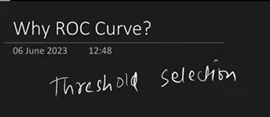

Threshold selection is the no we have to choose for classifying each class. For example, 0.5 could be a threshold

0.5 is a not great threshold every time. for example in email-spam detection we could set the threshold to 0.75 because a false positive is dangerous so the threshold is dependent on the use case and we use ROC curve for making an educated guess about it

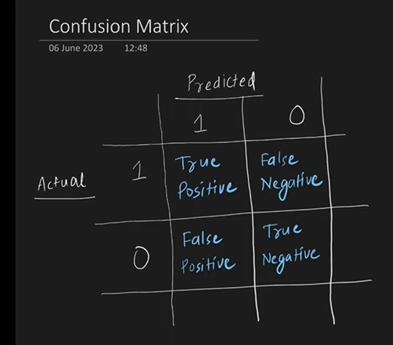

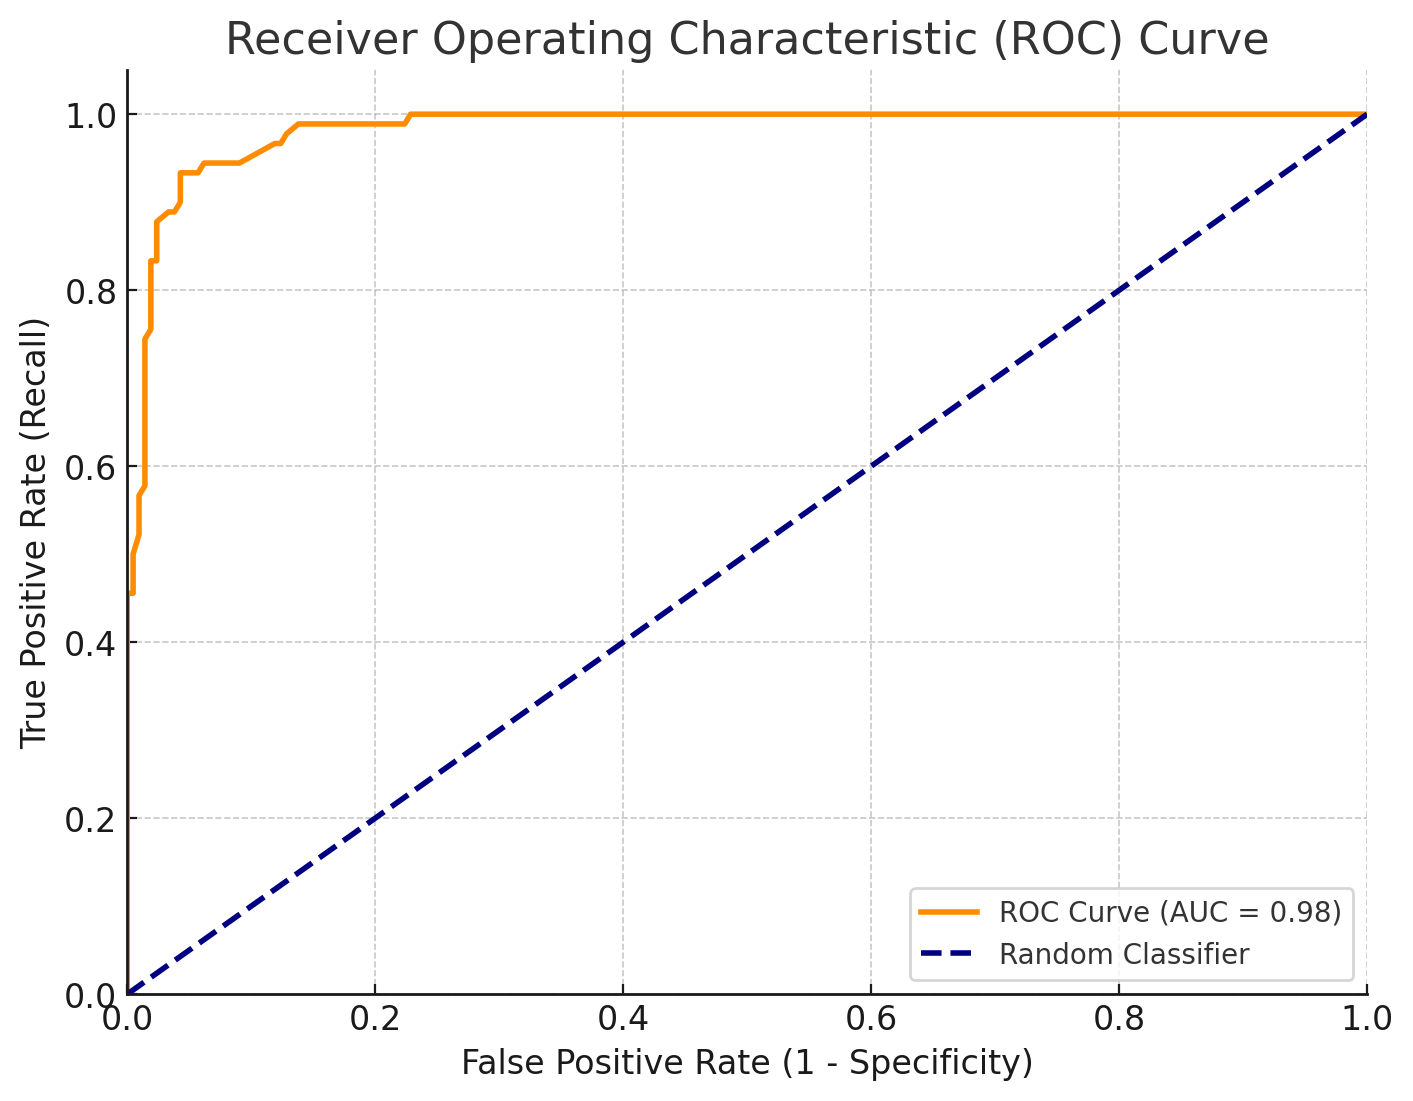

### ✅ ROC Curve Interpretation

The ROC curve (Receiver Operating Characteristic) plots:

* **X-axis** → False Positive Rate (FPR) = $\frac{FP}{FP + TN}$
* **Y-axis** → True Positive Rate (TPR) = Recall = $\frac{TP}{TP + FN}$

---

### 🧠 Insights:

1. **The closer the curve is to the top-left**, the better the model.
2. **The diagonal dashed line** is a **random guess** — any model **above it is useful**, below is worse than random.
3. **AUC (Area Under Curve)** = summary of model performance

   * AUC = 1.0 → Perfect classifier
   * AUC = 0.5 → Random classifier
   * AUC < 0.5 → Model is worse than random (flipping predictions would help)

---

### 🧪 In this Plot:

* The **orange curve** is the model's performance
* **AUC = high (e.g. > 0.9)** means good separation of positive and negative classes

---



### 🎯 Choosing the **Optimal Threshold** using ROC Curve

---

By default, classifiers use **threshold = 0.5** to decide class labels from predicted probabilities.
But this isn’t always optimal — especially with **imbalanced data** or different **costs for FP/FN**.

The **ROC curve helps visualize** how different thresholds affect:

* **True Positive Rate (TPR)** = Recall
* **False Positive Rate (FPR)**

---

## 🧠 Core Idea:

We want to **select a threshold** that:

* Maximizes **sensitivity (TPR)** while
* Minimizing **false alarms (FPR)**

---

## 🔧 Method 1: Find Threshold Closest to Perfect Classifier (0,1)

The point (0,1) on ROC curve is **ideal** — 100% TPR, 0% FPR.

So we calculate the **Euclidean distance** from each ROC point to (0,1), and pick the threshold with **smallest distance**.

### ✅ Code Example:

```python
from sklearn.metrics import roc_curve
import numpy as np

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Compute distance to top-left (0,1)
distance = np.sqrt((1 - tpr)**2 + fpr**2)
optimal_idx = np.argmin(distance)
optimal_threshold = thresholds[optimal_idx]

print("Optimal threshold:", optimal_threshold)
```

---

## 🔧 Method 2: Youden’s J statistic

Choose the threshold that **maximizes**:

```math
J = TPR - FPR
```

This balances sensitivity and specificity.

### ✅ Code:

```python
j_scores = tpr - fpr
optimal_idx = np.argmax(j_scores)
optimal_threshold = thresholds[optimal_idx]
```

---

## 📈 Visualizing Thresholds

You can plot TPR and FPR vs threshold:

```python
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(thresholds, tpr, label='TPR (Recall)')
plt.plot(thresholds, 1 - fpr, label='TNR (Specificity)')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('TPR and TNR vs Threshold')
plt.legend()
plt.grid(True)
plt.show()
```

---

## 🧪 When to Shift Threshold?

| Situation                       | Strategy                             |
| ------------------------------- | ------------------------------------ |
| Imbalanced data                 | Lower threshold to improve recall    |
| Cost of false negatives is high | Lower threshold (catch more)         |
| Cost of false positives is high | Raise threshold (avoid false alarms) |
| Balanced data, equal costs      | Use Youden’s J or distance method    |

---




In [1]:
import pandas as pd

data = pd.read_csv('https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv')

data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
X = data.drop('Outcome', axis=1)
y = data['Outcome']


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)


In [4]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [5]:
y_scores = model.predict_proba(X_test)[:,1]

In [6]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_scores)

In [7]:
thresholds

array([       inf, 0.99354348, 0.95264724, 0.95241788, 0.82462276,
       0.76876372, 0.76188926, 0.68388954, 0.67535572, 0.67413206,
       0.65126349, 0.65068001, 0.63553664, 0.58634233, 0.57566401,
       0.56978645, 0.52523706, 0.47020949, 0.46121678, 0.45049237,
       0.43902612, 0.43867708, 0.42231697, 0.41996866, 0.41308804,
       0.4119369 , 0.40487706, 0.37965315, 0.36862166, 0.31028537,
       0.30879832, 0.27781401, 0.27207356, 0.25519131, 0.2551397 ,
       0.24745452, 0.2455057 , 0.2367156 , 0.22883633, 0.18188702,
       0.17867316, 0.17460509, 0.17329306, 0.14646377, 0.14079261,
       0.11675751, 0.11492821, 0.11003673, 0.10665624, 0.08925616,
       0.08674905, 0.02002041, 0.01931826, 0.00160894])

In [8]:
import plotly.graph_objects as go
import numpy as np


# Generate a trace for ROC curve
trace0 = go.Scatter(
    x=fpr,
    y=tpr,
    mode='lines',
    name='ROC curve'
)

# Only label every nth point to avoid cluttering
n = 10
indices = np.arange(len(thresholds)) % n == 0  # Choose indices where index mod n is 0

trace1 = go.Scatter(
    x=fpr[indices],
    y=tpr[indices],
    mode='markers+text',
    name='Threshold points',
    text=[f"Thr={thr:.2f}" for thr in thresholds[indices]],
    textposition='top center'
)


# Diagonal line
trace2 = go.Scatter(
    x=[0, 1],
    y=[0, 1],
    mode='lines',
    name='Random (Area = 0.5)',
    line=dict(dash='dash')
)

data = [trace0, trace1, trace2]

# Define layout with square aspect ratio
layout = go.Layout(
    title='Receiver Operating Characteristic',
    xaxis=dict(title='False Positive Rate'),
    yaxis=dict(title='True Positive Rate'),
    autosize=False,
    width=800,
    height=800,
    showlegend=False
)

# Define figure and add data
fig = go.Figure(data=data, layout=layout)

# Show figure
fig.show()


In [9]:
# Assume that fpr, tpr, thresholds have already been calculated
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print("Optimal threshold is:", optimal_threshold)


Optimal threshold is: 0.3686216638384235


In [10]:
import plotly.graph_objects as go
import numpy as np
from sklearn.metrics import roc_auc_score

# Assuming fpr, tpr, thresholds are already calculated as before
fpr, tpr, thresholds = roc_curve(y_test, y_scores)

# Calculate the AUC (Area Under the Curve)
roc_auc = roc_auc_score(y_test, y_scores)

# Generate a trace for ROC curve
trace0 = go.Scatter(
    x=fpr,
    y=tpr,
    mode='lines',
    name=f'ROC curve (Area = {roc_auc:.2f})'
)

# Only label every nth point to avoid cluttering
n = 10
indices = np.arange(len(thresholds)) % n == 0  # Choose indices where index mod n is 0

trace1 = go.Scatter(
    x=fpr[indices],
    y=tpr[indices],
    mode='markers+text',
    name='Threshold points',
    text=[f"Thr={thr:.2f}" for thr in thresholds[indices]],
    textposition='top center'
)

# Diagonal line
trace2 = go.Scatter(
    x=[0, 1],
    y=[0, 1],
    mode='lines',
    name='Random (Area = 0.5)',
    line=dict(dash='dash')
)

data = [trace0, trace1, trace2]

# Define layout with square aspect ratio
layout = go.Layout(
    title='Receiver Operating Characteristic',
    xaxis=dict(title='False Positive Rate'),
    yaxis=dict(title='True Positive Rate'),
    autosize=False,
    width=800,
    height=800,
    showlegend=True
)

# Define figure and add data
fig = go.Figure(data=data, layout=layout)

# Show figure
fig.show()


In [11]:
import numpy as np
import plotly.graph_objects as go
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler

# Assuming that X_train, X_test, y_train, y_test are already defined

# SVM requires feature scaling for better performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression model
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_scores = lr_model.predict_proba(X_test)[:,1]

# SVM model
svm_model = SVC(probability=True)
svm_model.fit(X_train_scaled, y_train)
svm_scores = svm_model.predict_proba(X_test_scaled)[:,1]

# Generate ROC curve data for logistic regression model
lr_fpr, lr_tpr, lr_thresholds = roc_curve(y_test, lr_scores)
lr_auc = roc_auc_score(y_test, lr_scores)

# Generate ROC curve data for SVM model
svm_fpr, svm_tpr, svm_thresholds = roc_curve(y_test, svm_scores)
svm_auc = roc_auc_score(y_test, svm_scores)

# Generate a trace for the Logistic Regression ROC curve
trace0 = go.Scatter(
    x=lr_fpr,
    y=lr_tpr,
    mode='lines',
    name=f'Logistic Regression (Area = {lr_auc:.2f})'
)

# Generate a trace for the SVM ROC curve
trace1 = go.Scatter(
    x=svm_fpr,
    y=svm_tpr,
    mode='lines',
    name=f'SVM (Area = {svm_auc:.2f})'
)

# Diagonal line
trace2 = go.Scatter(
    x=[0, 1],
    y=[0, 1],
    mode='lines',
    name='Random (Area = 0.5)',
    line=dict(dash='dash')
)

data = [trace0, trace1, trace2]

# Define layout with square aspect ratio
layout = go.Layout(
    title='Receiver Operating Characteristic',
    xaxis=dict(title='False Positive Rate'),
    yaxis=dict(title='True Positive Rate'),
    autosize=False,
    width=800,
    height=800,
    showlegend=True
)

# Define figure and add data
fig = go.Figure(data=data, layout=layout)

# Show figure
fig.show()


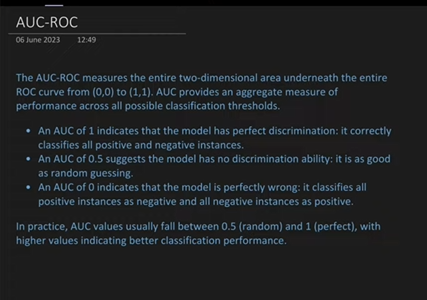

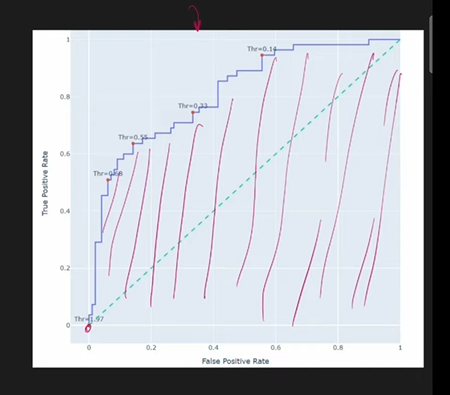